# 04 — Predictive Modeling
Train and evaluate models to predict next-season PPR fantasy points.

**Models compared:**
1. Naive Baseline (predict next year = this year)
2. Linear Regression
3. Ridge Regression
4. Random Forest
5. Gradient Boosting
6. XGBoost (if installed)

**Train/Val/Test split:** 2016–2021 / 2022 / 2023 (time-based, no leakage)

**Run notebook 03 first** to populate the `model_ready` table.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.predictor import (
    load_model_data,
    train_and_evaluate,
    get_feature_importance,
    FEATURE_COLS,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
%matplotlib inline

## 1. Load Model-Ready Data

In [2]:
df = load_model_data()
print(f'Model dataset shape: {df.shape}')
print(f'Seasons: {sorted(df["season"].unique())}')
print(f'Positions: {df["position"].value_counts().to_dict()}')
df.head(3)

Model dataset shape: (4058, 24)
Seasons: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Positions: {'WR': 1546, 'RB': 1144, 'TE': 862, 'QB': 506}


,player_id,full_name,position,season,ppr_pts_next,age_at_season,ppr_pts_prev1,ppr_pts_prev2,fantasy_points_ppr,ppr_per_game,td_rate,target_share,air_yards_share,targets_per_game,carries_per_game,avg_snap_pct,receiving_epa,rushing_epa,passing_epa,racr,pos_QB,pos_RB,pos_WR,pos_TE
0,00-0006101,Tony Gonzalez,TE,2012,218.90,36.5,NaN,NaN,234.00,14.625,0.500,3.171097,3.236721,7.75,0.000,NaN,61.123664,0.000000,0.000000,16.35189,0,0,0,1
1,00-0007091,Matt Hasselbeck,QB,2012,16.94,36.9,NaN,NaN,76.48,9.560,0.875,0.000000,0.000000,0.00,1.625,NaN,0.000000,-3.944240,-14.856310,0.00000,1,0,0,0
2,00-0007091,Matt Hasselbeck,QB,2014,91.10,38.9,76.48,NaN,16.94,4.235,0.500,0.000000,0.000000,0.00,2.000,0.305,0.000000,-7.756981,-0.628051,0.00000,1,0,0,0


## 2. Available Features

In [3]:
available_features = [c for c in FEATURE_COLS if c in df.columns]
print(f'{len(available_features)} features available:')
for f in available_features:
    null_pct = df[f].isna().mean() * 100
    print(f'  {f:35s} — {null_pct:.1f}% null')

19 features available:
  age_at_season                       — 0.0% null
  ppr_pts_prev1                       — 29.8% null
  ppr_pts_prev2                       — 50.7% null
  fantasy_points_ppr                  — 0.0% null
  ppr_per_game                        — 0.0% null
  td_rate                             — 0.0% null
  target_share                        — 0.0% null
  air_yards_share                     — 0.0% null
  targets_per_game                    — 0.0% null
  carries_per_game                    — 0.0% null
  avg_snap_pct                        — 8.0% null
  receiving_epa                       — 0.0% null
  rushing_epa                         — 0.0% null
  passing_epa                         — 0.0% null
  racr                                — 0.0% null
  pos_QB                              — 0.0% null
  pos_RB                              — 0.0% null
  pos_WR                              — 0.0% null
  pos_TE                              — 0.0% null


## 3. Train & Evaluate All Models

In [4]:
results, pred_df = train_and_evaluate(df)

Train: 3387 | Val: 340 | Test: 331

=== Validation Results ===
  Naive Baseline (prev year)     | MAE:  69.05 | RMSE:  94.00 | R²: -0.077
  Linear Regression              | MAE:  46.31 | RMSE:  60.66 | R²: 0.551
  Ridge Regression               | MAE:  46.25 | RMSE:  60.59 | R²: 0.552
  Random Forest                  | MAE:  46.63 | RMSE:  61.32 | R²: 0.542
  Gradient Boosting              | MAE:  47.43 | RMSE:  62.23 | R²: 0.528
  XGBoost                        | MAE:  46.77 | RMSE:  61.14 | R²: 0.544

Best model on validation: Ridge Regression (MAE=46.25)

=== Test Results (best model) ===
  Ridge Regression               | MAE:  48.26 | RMSE:  63.87 | R²: 0.513


## 4. Results Comparison

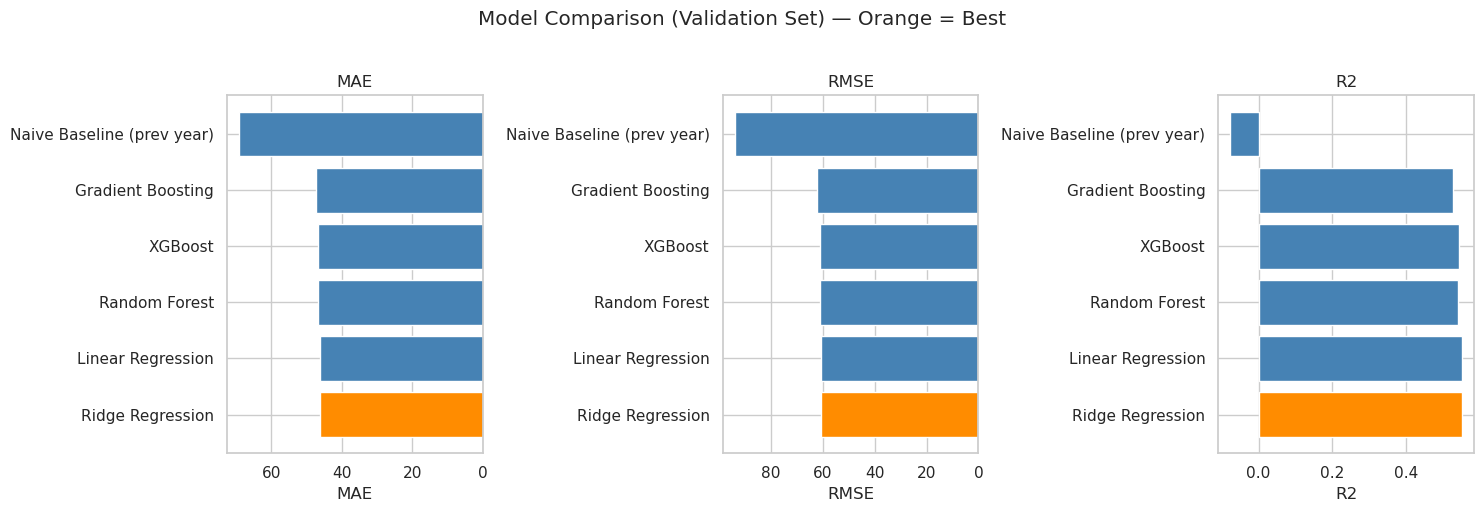


Best model: Ridge Regression


,model,mae,rmse,r2
2,Ridge Regression,46.245321,60.590037,0.552464
1,Linear Regression,46.312293,60.663864,0.551373
3,Random Forest,46.633307,61.315661,0.541681
5,XGBoost,46.770935,61.137471,0.544341
4,Gradient Boosting,47.428376,62.227108,0.527954
0,Naive Baseline (prev year),69.053412,94.000005,-0.077162


In [5]:
results_df = pd.DataFrame(results['results'])
results_df = results_df.sort_values('mae')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['mae', 'rmse', 'r2']):
    colors = ['steelblue' if m != results['best_model'] else 'darkorange' 
              for m in results_df['model']]
    ax.barh(results_df['model'], results_df[metric], color=colors)
    ax.set_title(metric.upper())
    ax.set_xlabel(metric.upper())
    if metric in ['mae', 'rmse']:
        ax.invert_xaxis()  # lower is better
plt.suptitle('Model Comparison (Validation Set) — Orange = Best', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nBest model: {results['best_model']}")
results_df

## 5. Feature Importance (Random Forest)

Train: 3387 | Val: 340 | Test: 331
Top 15 features:
           feature  importance
      ppr_per_game    0.433050
fantasy_points_ppr    0.308093
     age_at_season    0.038250
     ppr_pts_prev1    0.036528
       rushing_epa    0.021793
              racr    0.021268
      avg_snap_pct    0.019057
           td_rate    0.017360
   air_yards_share    0.016139
       passing_epa    0.015489
      target_share    0.015229
     receiving_epa    0.014933
     ppr_pts_prev2    0.013913
  carries_per_game    0.013576
  targets_per_game    0.013011


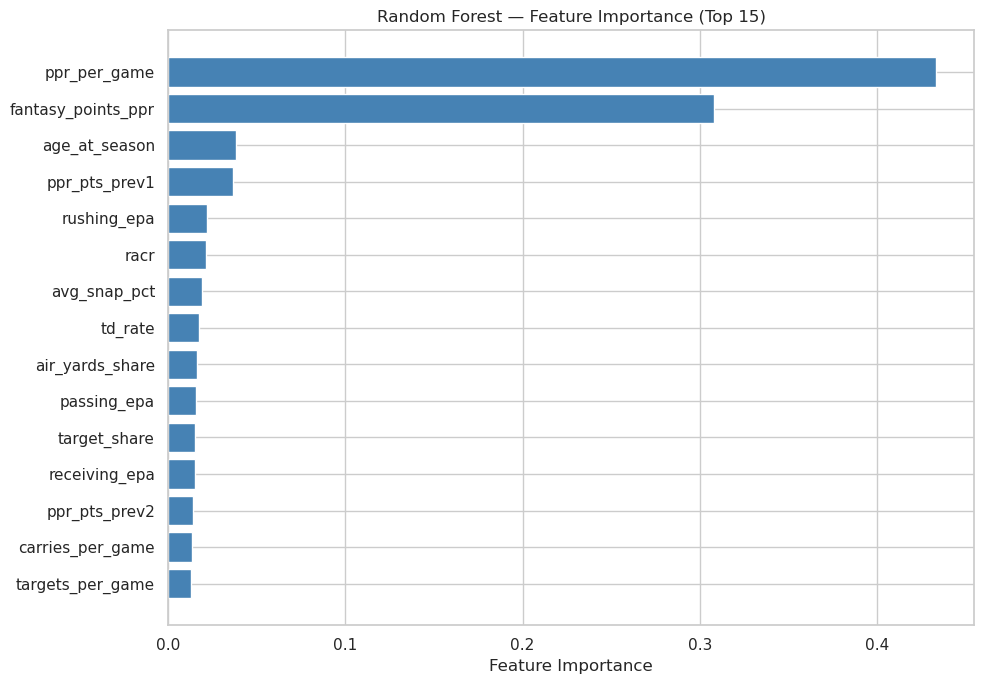

In [6]:
feat_df = get_feature_importance(df)
print('Top 15 features:')
print(feat_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top_feats = feat_df.head(15)
ax.barh(top_feats['feature'][::-1], top_feats['importance'][::-1], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest — Feature Importance (Top 15)')
plt.tight_layout()
plt.show()

## 6. Predicted vs Actual (Test Set)

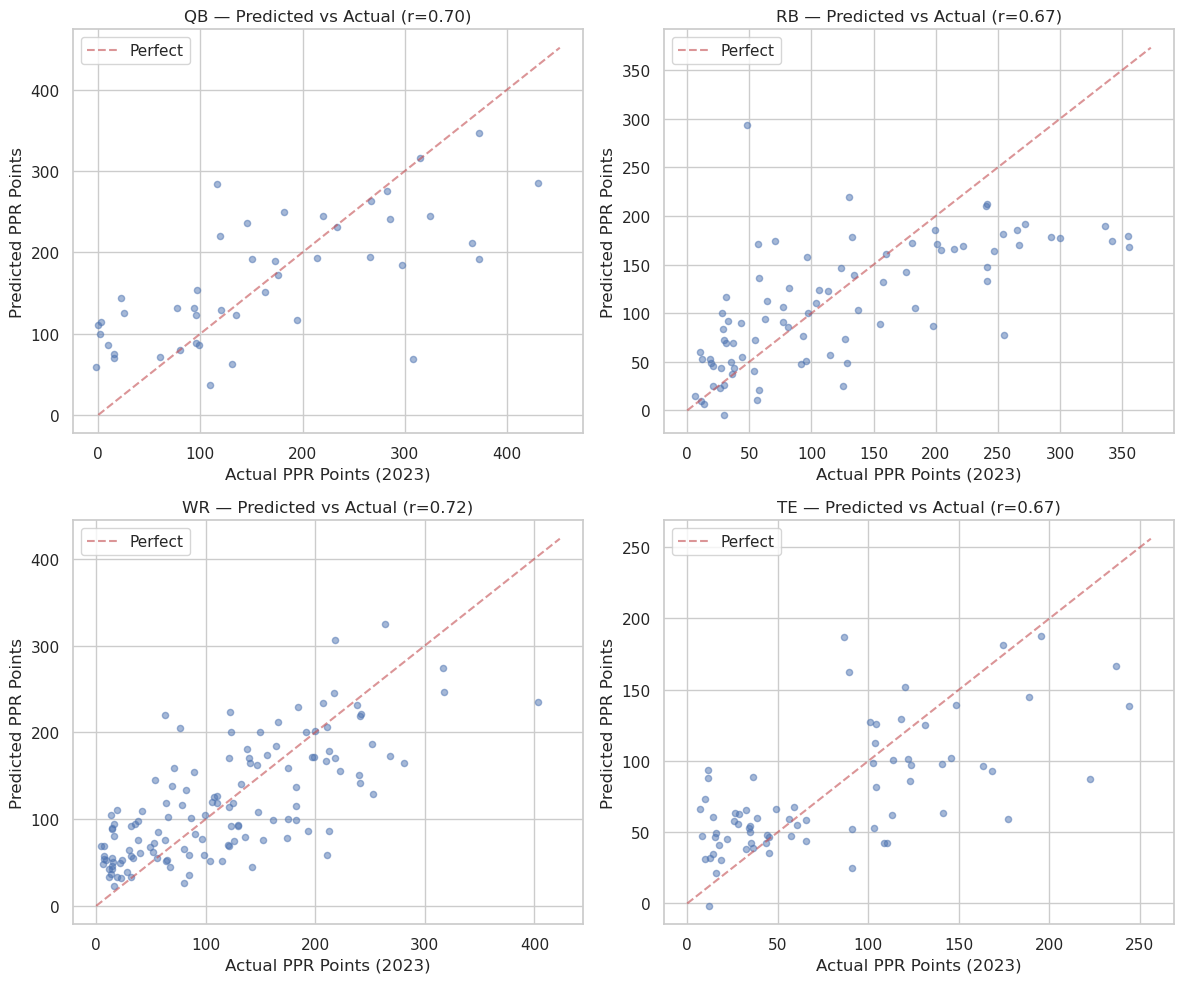

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, pos in zip(axes.flatten(), ['QB', 'RB', 'WR', 'TE']):
    if 'position' not in pred_df.columns:
        break
    sub = pred_df[pred_df['position'] == pos]
    ax.scatter(sub['actual_ppr_next'], sub['predicted_ppr_next'], alpha=0.5, s=20)
    lim = max(sub['actual_ppr_next'].max(), sub['predicted_ppr_next'].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', alpha=0.6, label='Perfect')
    corr = sub[['actual_ppr_next', 'predicted_ppr_next']].corr().iloc[0, 1]
    ax.set_title(f'{pos} — Predicted vs Actual (r={corr:.2f})')
    ax.set_xlabel('Actual PPR Points (2023)')
    ax.set_ylabel('Predicted PPR Points')
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Dynasty Draft Rankings Output
Top predicted players for next season — your dynasty draft tool output.

In [8]:
print('=== Overall Top 30 by Predicted PPR ===')
display_cols = ['predicted_rank', 'full_name', 'position', 'predicted_ppr_next', 'actual_ppr_next', 'error']
available_display = [c for c in display_cols if c in pred_df.columns]
pred_df[available_display].head(30)

=== Overall Top 30 by Predicted PPR ===


,predicted_rank,full_name,position,predicted_ppr_next,actual_ppr_next,error
0,1,Josh Allen,QB,347.493899,372.34,-24.846101
1,2,CeeDee Lamb,WR,325.248392,263.40,61.848392
2,3,Jalen Hurts,QB,316.010883,315.12,0.890883
3,4,Tyreek Hill,WR,306.737341,218.20,88.537341
4,5,Christian McCaffrey,RB,293.364003,47.80,245.564003
5,6,Lamar Jackson,QB,284.813402,430.38,-145.566598
6,7,Dak Prescott,QB,283.716317,116.52,167.196317
7,8,Patrick Mahomes,QB,275.742642,283.02,-7.277358
8,9,Amon-Ra St. Brown,WR,274.595017,316.18,-41.584983
9,10,Brock Purdy,QB,263.428702,266.86,-3.431298


In [9]:
# Rankings by position
for pos in ['QB', 'RB', 'WR', 'TE']:
    if 'position' in pred_df.columns:
        sub = pred_df[pred_df['position'] == pos].head(10)
        print(f'\n=== Top 10 {pos}s ===')
        print(sub[available_display].to_string(index=False))


=== Top 10 QBs ===
 predicted_rank       full_name position  predicted_ppr_next  actual_ppr_next       error
              1      Josh Allen       QB          347.493899           372.34  -24.846101
              3     Jalen Hurts       QB          316.010883           315.12    0.890883
              6   Lamar Jackson       QB          284.813402           430.38 -145.566598
              7    Dak Prescott       QB          283.716317           116.52  167.196317
              8 Patrick Mahomes       QB          275.742642           283.02   -7.277358
             10     Brock Purdy       QB          263.428702           266.86   -3.431298
             11  Tua Tagovailoa       QB          249.683597           181.58   68.103597
             14      Jared Goff       QB          245.208394           324.46  -79.251606
             15     C.J. Stroud       QB          244.464023           220.38   24.084023
             16  Justin Herbert       QB          241.264563           285.40  -

## 8. Biggest Misses
Identify where the model was most wrong — useful for understanding its limits.

In [10]:
pred_df['abs_error'] = pred_df['error'].abs()
worst = pred_df.nlargest(15, 'abs_error')
print('15 biggest prediction errors on test set:')
err_cols = ['full_name', 'position', 'predicted_ppr_next', 'actual_ppr_next', 'error']
available_err = [c for c in err_cols if c in worst.columns]
worst[available_err]

15 biggest prediction errors on test set:


,full_name,position,predicted_ppr_next,actual_ppr_next,error
4,Christian McCaffrey,RB,293.364003,47.80,245.564003
220,Sam Darnold,QB,68.783195,307.96,-239.176805
75,Saquon Barkley,RB,168.383907,355.30,-186.916093
42,Joe Burrow,QB,191.504399,372.82,-181.315601
200,Chase Brown,RB,78.071850,255.00,-176.928150
55,Jahmyr Gibbs,RB,179.595482,354.90,-175.304518
17,Ja'Marr Chase,WR,235.367241,403.00,-167.632759
60,Bijan Robinson,RB,174.265448,341.70,-167.434552
6,Dak Prescott,QB,283.716317,116.52,167.196317
24,Brandon Aiyuk,WR,220.403700,62.40,158.003700
